# 10 — Does funding eat the edge?

Funding data covers **all 173 symbols** for 2025 & 2026 (4h cadence). For a
short, positive funding = we receive, negative = we pay. We sum funding over
each trade's holding window and fold it into PnL.

Layers: price-only -> +funding -> +funding +trading cost (net).

In [1]:
import sys; sys.path.insert(0, '.')
from _lab import *
import heapq

COST = 0.0015
def load(tag):
    d = np.load(f'_out/funding_{tag}.npz')
    return d['ppnl'], d['fpnl'], d['ts'], d['off'], d['stamps']

p25, f25, ts25, off25, st25 = load('2025')
p26, f26, ts26, off26, st26 = load('2026')
print(f'2025 trades {len(p25)} | 2026 trades {len(p26)}')
print(f'funding stamps crossed: 0 -> {(st25==0).mean()*100:.0f}%, '
      f'1 -> {(st25==1).mean()*100:.0f}%, 2+ -> {(st25>=2).mean()*100:.0f}%  (2025)')
print(f'short pays funding in {(f25<0).mean()*100:.0f}% of trades, receives in {(f25>0).mean()*100:.0f}% (2025)')

2025 trades 2181 | 2026 trades 972
funding stamps crossed: 0 -> 51%, 1 -> 49%, 2+ -> 0%  (2025)
short pays funding in 24% of trades, receives in 25% (2025)


In [2]:
def stats(p):
    return (p.mean()*100, np.median(p)*100, (p>0).mean()*100, p.std()*100, p.mean()/p.std())
HDR = f"{'layer':<26}{'mean':>8}{'median':>8}{'win%':>7}{'std':>8}{'m/std':>7}"
def row(name, p):
    m, md, w, sd, sh = stats(p)
    print(f"{name:<26}{m:>+7.2f}%{md:>+7.2f}%{w:>6.1f}%{sd:>7.2f}%{sh:>7.3f}")

for tag, (pp, ff) in {'2025': (p25, f25), '2026': (p26, f26)}.items():
    print(f'--- {tag} ---'); print(HDR)
    row('price only', pp)
    row('+ funding', pp + ff)
    row('+ funding + cost (NET)', pp + ff - COST)
    print()

--- 2025 ---
layer                         mean  median   win%     std  m/std
price only                  +1.67%  +1.34%  56.6%   5.16%  0.324
+ funding                   +1.61%  +1.33%  56.4%   5.10%  0.315
+ funding + cost (NET)      +1.46%  +1.18%  55.8%   5.10%  0.286

--- 2026 ---
layer                         mean  median   win%     std  m/std
price only                  +2.06%  +0.80%  53.6%   5.77%  0.356
+ funding                   +1.93%  +0.74%  53.1%   5.71%  0.338
+ funding + cost (NET)      +1.78%  +0.59%  52.3%   5.71%  0.312



[saved] notebooks\pump\_out\10_funding.png


WindowsPath('C:/projects/researchlab/notebooks/pump/_out/10_funding.png')

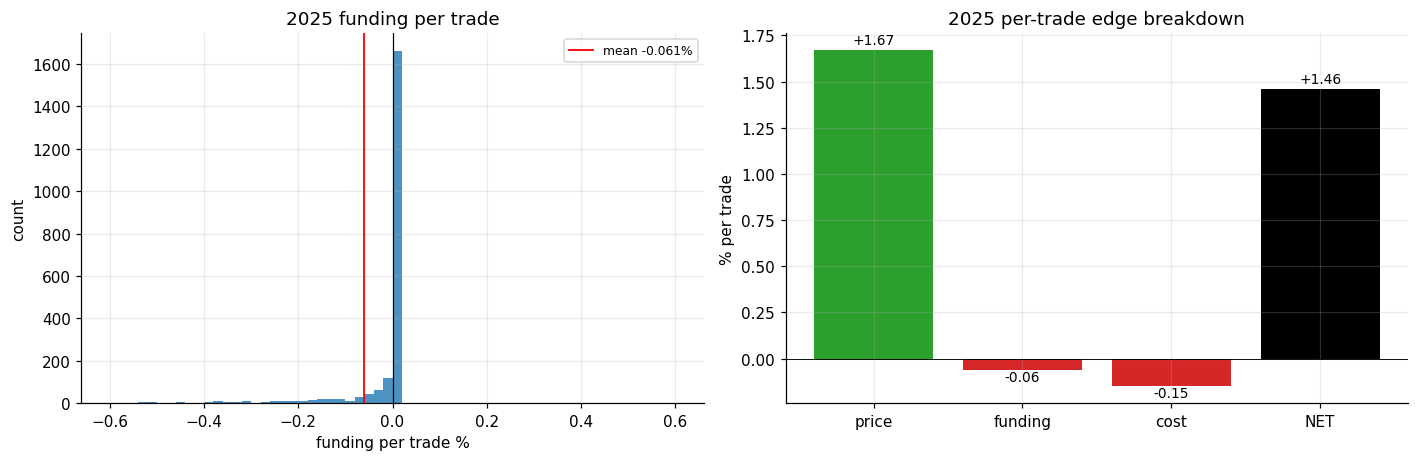

In [3]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.3))
a1.hist(f25*100, bins=np.linspace(-0.6, 0.6, 61), alpha=0.8)
a1.axvline(f25.mean()*100, color='r', lw=1.2, label=f'mean {f25.mean()*100:.3f}%')
a1.axvline(0, color='k', lw=0.8)
a1.set_xlabel('funding per trade %'); a1.set_ylabel('count'); a1.set_title('2025 funding per trade')
a1.legend(fontsize=8)
# edge breakdown bar
labels = ['price', 'funding', 'cost', 'NET']
vals = [p25.mean()*100, f25.mean()*100, -COST*100, (p25+f25-COST).mean()*100]
colors = ['tab:green', 'tab:red' if f25.mean()<0 else 'tab:green', 'tab:red', 'k']
a2.bar(labels, vals, color=colors)
a2.axhline(0, color='k', lw=0.6)
for i, v in enumerate(vals):
    a2.text(i, v + (0.03 if v >= 0 else -0.06), f'{v:+.2f}', ha='center', fontsize=9)
a2.set_ylabel('% per trade'); a2.set_title('2025 per-trade edge breakdown')
show('10_funding')

## Portfolio with funding included ($1000 / $20)

In [4]:
CAPITAL, SIZE = 1000.0, 20.0
def portfolio(net_pnl, ts, off):
    emin = ((ts - ts.min()) // (60*10**9)).astype(int); xmin = emin + off
    order = np.argsort(emin)
    eq = CAPITAL; comm = 0.0; op = []; ct, ce = [], []
    for k in order:
        now = emin[k]
        while op and op[0][0] <= now:
            _, d = heapq.heappop(op); eq += d; comm -= SIZE; ct.append(now); ce.append(eq)
        if eq - comm >= SIZE:
            heapq.heappush(op, (xmin[k], SIZE*net_pnl[k])); comm += SIZE
    while op:
        t, d = heapq.heappop(op); eq += d; comm -= SIZE; ct.append(t); ce.append(eq)
    s = pd.Series(ce, index=ct).sort_index()
    mdd = (s/s.cummax()-1).min()*100
    return eq, mdd

print(f"{'scenario':<26}{'final$':>10}{'return':>9}{'realDD':>8}")
for tag, (pp, ff, ts, off) in {'2025': (p25,f25,ts25,off25), '2026': (p26,f26,ts26,off26)}.items():
    fe0, dd0 = portfolio(pp - COST, ts, off)            # no funding (as in nb08/09)
    fe1, dd1 = portfolio(pp + ff - COST, ts, off)        # WITH funding
    print(f'{tag} no funding{"":<14}{fe0:>10,.0f}{(fe0/CAPITAL-1)*100:>+8.0f}%{dd0:>7.1f}%')
    print(f'{tag} WITH funding{"":<12}{fe1:>10,.0f}{(fe1/CAPITAL-1)*100:>+8.0f}%{dd1:>7.1f}%')


scenario                      final$   return  realDD
2025 no funding                   1,765     +77%   -6.5%
2025 WITH funding                 1,739     +74%   -6.6%
2026 no funding                   1,425     +43%   -3.2%
2026 WITH funding                 1,401     +40%   -3.2%
